In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from helpers import moving_average

In [3]:
eps_greedy_e01_lambda05_path = "../results/EpsilonGreedy_e=0.1_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763032116.json"
ucb_c2_lambda05_path = "../results/UCB_c=2.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763034405.json"
thompson_lambda05_path = "../results/ThompsonSampling_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763050930.json"

with open(eps_greedy_e01_lambda05_path, 'r') as f:
    eps_greedy_e01_lambda05_results = json.load(f)
with open(ucb_c2_lambda05_path, 'r') as f:
    ucb_c2_lambda05_results = json.load(f)
with open(thompson_lambda05_path, 'r') as f:
    thompson_lambda05_results = json.load(f)

In [4]:
# Check the fields in the results
print(eps_greedy_e01_lambda05_results.keys())
print(ucb_c2_lambda05_results.keys())
print(thompson_lambda05_results.keys())

dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])
dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])
dict_keys(['run_name', 'bandit', 'params', 'lambda_param', 'total_queries', 'avg_score', 'avg_latency', 'policy_proportions', 'rewards', 'scores', 'latencies', 'selected_arms', 'arm_map'])


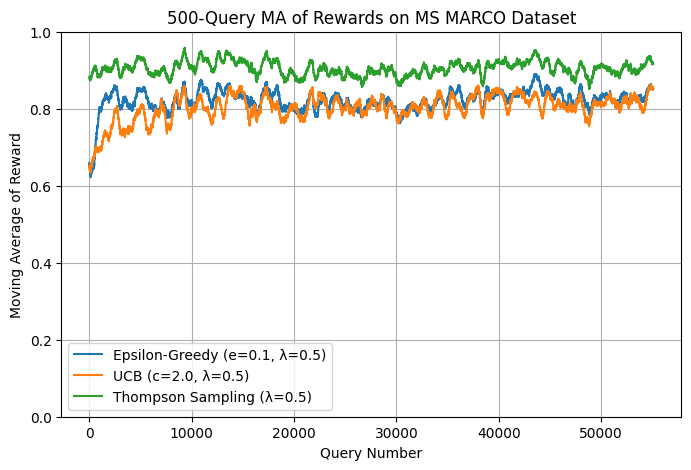

In [5]:
# Compute the moving averages of the rewards
WINDOW_SIZE = 500

eps_greedy_e01_lambda05_ma = moving_average(eps_greedy_e01_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
ucb_c2_lambda05_ma = moving_average(ucb_c2_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
thompson_lambda05_ma = moving_average(thompson_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages
plt.figure(figsize=(8, 5))
plt.plot(eps_greedy_e01_lambda05_ma, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.plot(ucb_c2_lambda05_ma, label='UCB (c=2.0, λ=0.5)')
plt.plot(thompson_lambda05_ma, label='Thompson Sampling (λ=0.5)')
plt.title(f'{WINDOW_SIZE}-Query MA of Rewards on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
IMAGES_DIR = '../images'
DATASET_NAME = 'msmarco'
os.makedirs(IMAGES_DIR, exist_ok=True)
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_mab_base_config_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

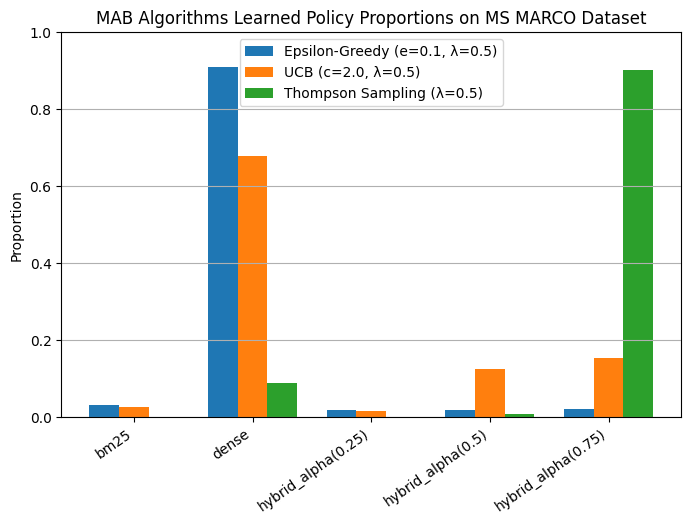

In [6]:
# Plot the policy proportions
eps_greedy_e01_lambda05_prop = eps_greedy_e01_lambda05_results['policy_proportions']
ucb_c2_lambda05_prop = ucb_c2_lambda05_results['policy_proportions']
thompson_lambda05_prop = thompson_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(eps_greedy_e01_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, eps_greedy_e01_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.bar(x, ucb_c2_lambda05_prop.values(), width, label='UCB (c=2.0, λ=0.5)')
plt.bar(x + width, thompson_lambda05_prop.values(), width, label='Thompson Sampling (λ=0.5)')
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('MAB Algorithms Learned Policy Proportions on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.legend()
plt.show()

In [8]:
eps_greedy_e001_lambda05_path = "../results/EpsilonGreedy_e=0.01_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763031720.json"
eps_greedy_e03_lambda05_path = "../results/EpsilonGreedy_e=0.3_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763032501.json"

with open(eps_greedy_e001_lambda05_path, 'r') as f:
    eps_greedy_e001_lambda05_results = json.load(f)
with open(eps_greedy_e03_lambda05_path, 'r') as f:
    eps_greedy_e03_lambda05_results = json.load(f)

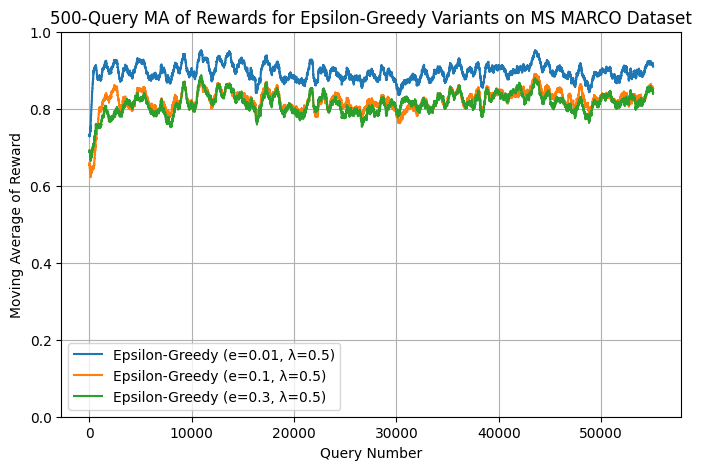

In [9]:
# Calculate moving averages
eps_greedy_e001_lambda05_ma = moving_average(eps_greedy_e001_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
eps_greedy_e03_lambda05_ma = moving_average(eps_greedy_e03_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages for different epsilon values
plt.figure(figsize=(8, 5))
plt.plot(eps_greedy_e001_lambda05_ma, label='Epsilon-Greedy (e=0.01, λ=0.5)')
plt.plot(eps_greedy_e01_lambda05_ma, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.plot(eps_greedy_e03_lambda05_ma, label='Epsilon-Greedy (e=0.3, λ=0.5)')
plt.title(f'{WINDOW_SIZE}-Query MA of Rewards for Epsilon-Greedy Variants on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_eps_greedy_different_e_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

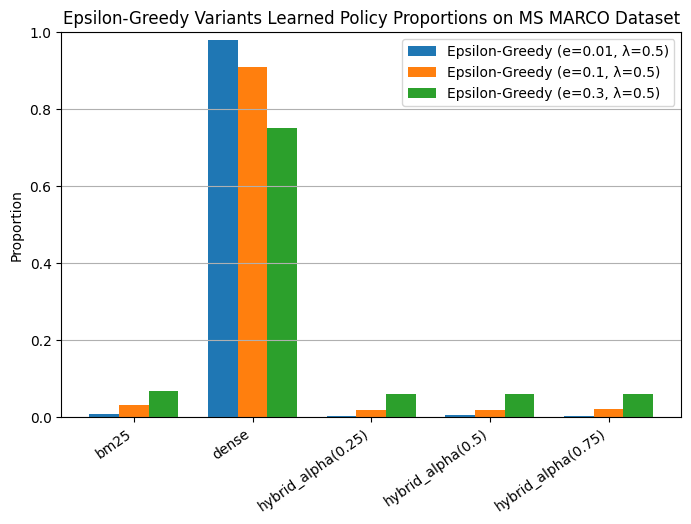

In [10]:
# Plot the policy proportions for different epsilon values
eps_greedy_e001_lambda05_prop = eps_greedy_e001_lambda05_results['policy_proportions']
eps_greedy_e03_lambda05_prop = eps_greedy_e03_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(eps_greedy_e001_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, eps_greedy_e001_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.01, λ=0.5)')
plt.bar(x, eps_greedy_e01_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.1, λ=0.5)')
plt.bar(x + width, eps_greedy_e03_lambda05_prop.values(), width, label='Epsilon-Greedy (e=0.3, λ=0.5)')
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('Epsilon-Greedy Variants Learned Policy Proportions on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.legend()
plt.show()

In [11]:
ucb_c1_lambda05_path = "../results/UCB_c=1.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763033873.json"
ucb_c3_lambda05_path = "../results/UCB_c=3.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco_1763034893.json"

with open(ucb_c1_lambda05_path, 'r') as f:
    ucb_c1_lambda05_results = json.load(f)
with open(ucb_c3_lambda05_path, 'r') as f:
    ucb_c3_lambda05_results = json.load(f)

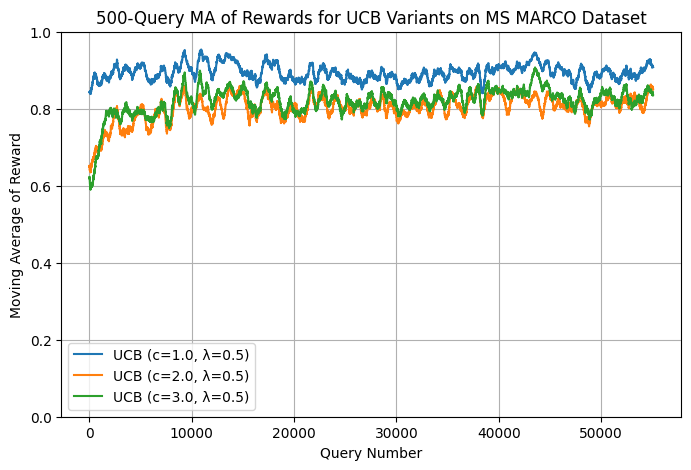

In [12]:
# Caclculate moving averages
ucb_c1_lambda05_ma = moving_average(ucb_c1_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')
ucb_c3_lambda05_ma = moving_average(ucb_c3_lambda05_results['rewards'], WINDOW_SIZE, mode='valid')

# Plot the moving averages for different UCB c values
plt.figure(figsize=(8, 5))
plt.plot(ucb_c1_lambda05_ma, label='UCB (c=1.0, λ=0.5)')
plt.plot(ucb_c2_lambda05_ma, label='UCB (c=2.0, λ=0.5)')
plt.plot(ucb_c3_lambda05_ma, label='UCB (c=3.0, λ=0.5)')
plt.title(f'{WINDOW_SIZE}-Query MA of Rewards for UCB Variants on MS MARCO Dataset')
plt.xlabel('Query Number')
plt.ylabel('Moving Average of Reward')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Save the plot
plt.savefig(
    os.path.join(IMAGES_DIR, f'{DATASET_NAME}_ucb_different_c_{WINDOW_SIZE}_ma_rewards.png'),
    bbox_inches='tight',
    dpi=300
)

# Show the plot
plt.show()

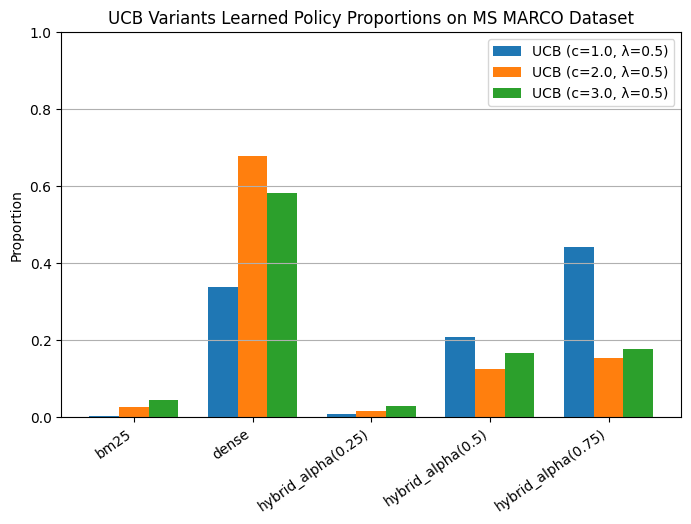

In [13]:
# Plot the policy proportions for different c values
ucb_c1_lambda05_prop = ucb_c1_lambda05_results['policy_proportions']
ucb_c3_lambda05_prop = ucb_c3_lambda05_results['policy_proportions']

# Plot the proportions on a grouped bar chart
policies = list(ucb_c1_lambda05_prop.keys())
x = np.arange(len(policies))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, ucb_c1_lambda05_prop.values(), width, label='UCB (c=1.0, λ=0.5)')
plt.bar(x, ucb_c2_lambda05_prop.values(), width, label='UCB (c=2.0, λ=0.5)')
plt.bar(x + width, ucb_c3_lambda05_prop.values(), width, label='UCB (c=3.0, λ=0.5)')
plt.xticks(x, policies, rotation=35, ha='right')
plt.ylabel('Proportion')
plt.title('UCB Variants Learned Policy Proportions on MS MARCO Dataset')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.legend()
plt.show()